In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_excel('visa_status_dataset.xlsx')

In [3]:
df.head()

,application_date,decision_date,visa_status,nationality,processing_center,applicant_age,gender,application_id
0,2019-11-27,2020-08-12,Approved,NaN,Dublin,NaN,Other,781436
1,2024-02-04,2024-07-24,NaN,Nigeria,NaN,30.0,Other,904539
2,2019-08-19,2021-10-15,Refused,Nigeria,Sydney,45.0,Other,114944
3,2020-12-29,2022-08-12,Pending,NaN,Dublin,45.0,Female,414037
4,2022-02-13,2024-04-24,Administrative Processing,Nigeria,New Delhi,60.0,Other,321361


In [4]:
from datetime import datetime

In [5]:
df['application_date']=pd.to_datetime(df['application_date'])
df['decision_date']=pd.to_datetime(df['decision_date'])

In [6]:
df['processing_days']=(df['decision_date']-df['application_date']).dt.days

In [7]:
df.isnull().sum()

application_date        0
decision_date           0
visa_status          6548
nationality          5428
processing_center    5473
applicant_age        5549
gender               8224
application_id          0
processing_days         0
dtype: int64

In [8]:
# Filling Missing Values

df['visa_status'].fillna('unknown', inplace=True)
df['nationality'].fillna('unknown',inplace=True)
df['processing_center'].fillna('unknown',inplace=True)
df['applicant_age']=df['applicant_age'].fillna(df['applicant_age'].mean()).round().astype(int)
df['gender'].fillna(df['gender'].mode()[0],inplace=True)

In [9]:
df.head()

,application_date,decision_date,visa_status,nationality,processing_center,applicant_age,gender,application_id,processing_days
0,2019-11-27,2020-08-12,Approved,unknown,Dublin,35,Other,781436,259
1,2024-02-04,2024-07-24,unknown,Nigeria,unknown,30,Other,904539,171
2,2019-08-19,2021-10-15,Refused,Nigeria,Sydney,45,Other,114944,788
3,2020-12-29,2022-08-12,Pending,unknown,Dublin,45,Female,414037,591
4,2022-02-13,2024-04-24,Administrative Processing,Nigeria,New Delhi,60,Other,321361,801


In [10]:
df=df[df['processing_days']<365]

In [11]:
df.shape

(5977, 9)

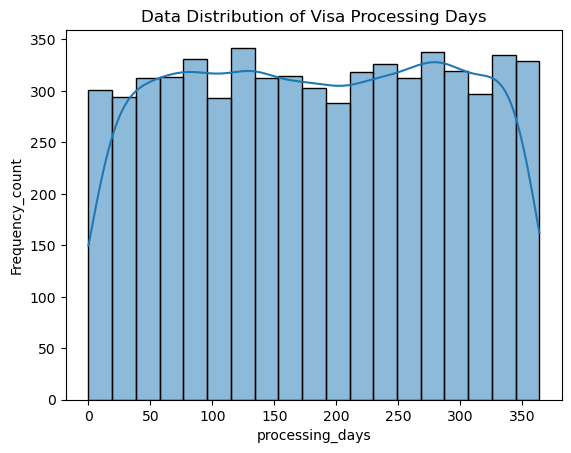

In [12]:
sns.histplot(df['processing_days'],kde=True)
plt.title('Data Distribution of Visa Processing Days')
plt.xlabel('processing_days')
plt.ylabel('Frequency_count')
plt.show()

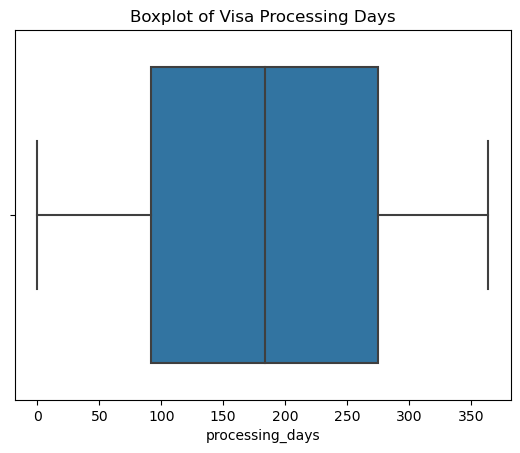

In [13]:
sns.boxplot(df['processing_days'])
plt.title('Boxplot of Visa Processing Days')
plt.show()

In [14]:
df['application_month']=df['application_date'].dt.month
df.head()

,application_date,decision_date,visa_status,nationality,processing_center,applicant_age,gender,application_id,processing_days,application_month
0,2019-11-27,2020-08-12,Approved,unknown,Dublin,35,Other,781436,259,11
1,2024-02-04,2024-07-24,unknown,Nigeria,unknown,30,Other,904539,171,2
6,2022-02-26,2022-09-15,Approved,Nigeria,unknown,18,Female,439606,201,2
22,2019-01-10,2019-08-27,Approved,Nigeria,Dublin,22,Male,185883,229,1
25,2023-11-29,2024-06-07,unknown,unknown,New Delhi,30,Female,336743,191,11


In [15]:
corr_mat=df[['processing_days','application_month']].corr()
print(corr_mat)

                   processing_days  application_month
processing_days           1.000000          -0.040771
application_month        -0.040771           1.000000


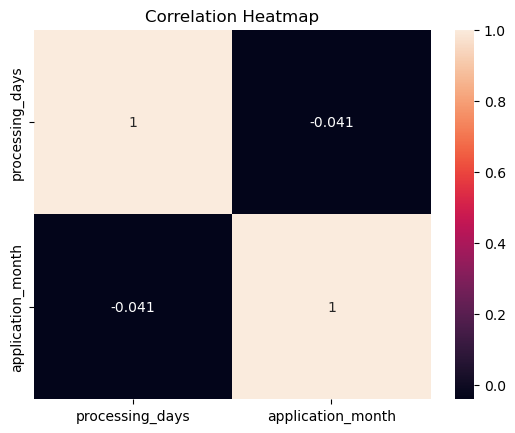

In [16]:
sns.heatmap(corr_mat,annot=True)
plt.title('Correlation Heatmap')
plt.show()

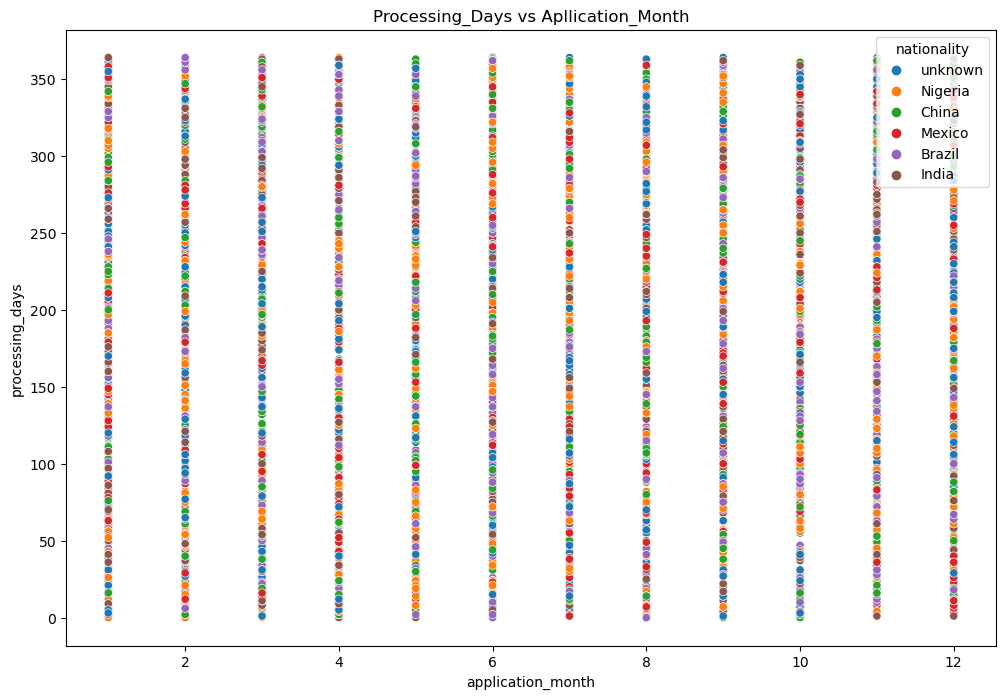

In [17]:
plt.figure(figsize=(12,8))
sns.scatterplot(df['application_month'],df['processing_days'],hue=df['nationality'])
plt.title('Processing_Days vs Apllication_Month')
plt.show()

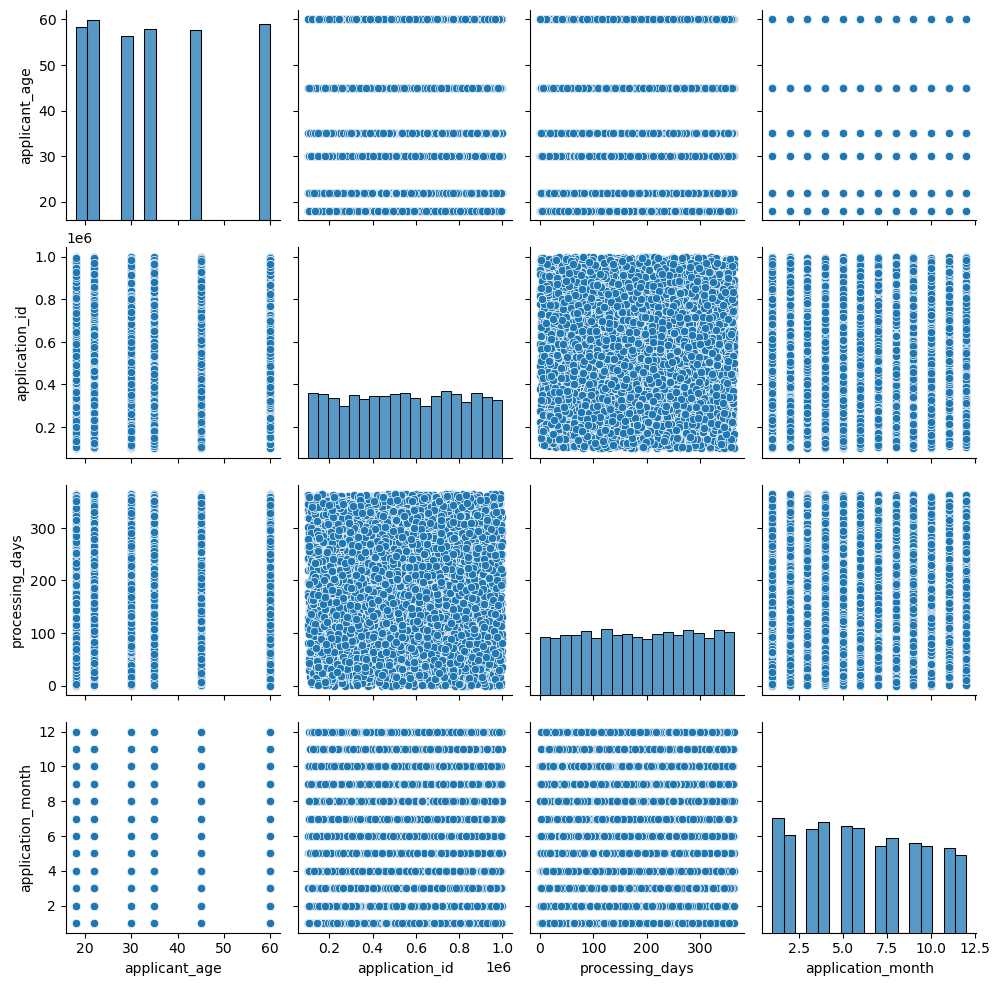

In [18]:
sns.pairplot(df)
plt.show()

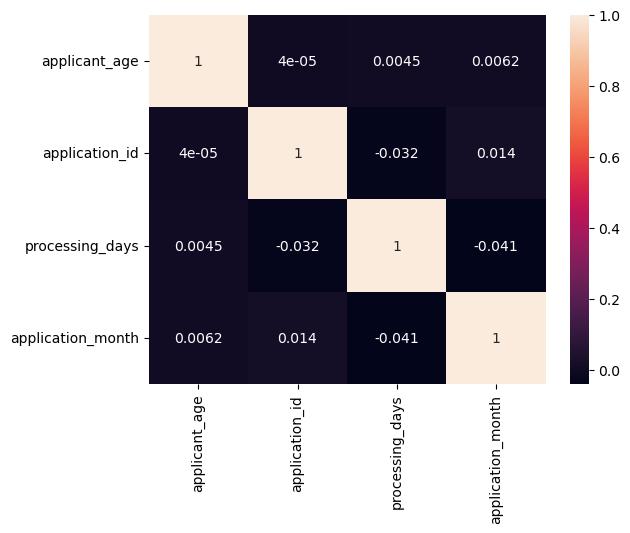

In [19]:
sns.heatmap(df.corr(),annot=True)
plt.show()

FEATURE ENGINEERING

In [20]:
# Feature 1
# Application Month

df[['application_date','application_month']].head()


,application_date,application_month
0,2019-11-27,11
1,2024-02-04,2
6,2022-02-26,2
22,2019-01-10,1
25,2023-11-29,11


In [21]:
# Feature 2
# Seasonal Index

df['season']=df['application_month'].apply(lambda x : 'Peak' if x in [1,2,12] else 'Off-Peak')
df[['application_month','season']].head()

,application_month,season
0,11,Off-Peak
1,2,Peak
6,2,Peak
22,1,Peak
25,11,Off-Peak


In [22]:
# Feature 3
# Country-Specific Average Processing Days

country_avg=df.groupby('nationality')['processing_days'].mean().round()
df['country_avg']=df['nationality'].map(country_avg)
df.head()

,application_date,decision_date,visa_status,nationality,processing_center,applicant_age,gender,application_id,processing_days,application_month,season,country_avg
0,2019-11-27,2020-08-12,Approved,unknown,Dublin,35,Other,781436,259,11,Off-Peak,183.0
1,2024-02-04,2024-07-24,unknown,Nigeria,unknown,30,Other,904539,171,2,Peak,183.0
6,2022-02-26,2022-09-15,Approved,Nigeria,unknown,18,Female,439606,201,2,Peak,183.0
22,2019-01-10,2019-08-27,Approved,Nigeria,Dublin,22,Male,185883,229,1,Peak,183.0
25,2023-11-29,2024-06-07,unknown,unknown,New Delhi,30,Female,336743,191,11,Off-Peak,183.0


In [23]:
# Feature 4
# Visa-Status Average Processing Time
visa_avg= df.groupby('visa_status')['processing_days'].mean().round()
df['visa_avg']=df['visa_status'].map(visa_avg)
df.head()

,application_date,decision_date,visa_status,nationality,processing_center,applicant_age,gender,application_id,processing_days,application_month,season,country_avg,visa_avg
0,2019-11-27,2020-08-12,Approved,unknown,Dublin,35,Other,781436,259,11,Off-Peak,183.0,187.0
1,2024-02-04,2024-07-24,unknown,Nigeria,unknown,30,Other,904539,171,2,Peak,183.0,188.0
6,2022-02-26,2022-09-15,Approved,Nigeria,unknown,18,Female,439606,201,2,Peak,183.0,187.0
22,2019-01-10,2019-08-27,Approved,Nigeria,Dublin,22,Male,185883,229,1,Peak,183.0,187.0
25,2023-11-29,2024-06-07,unknown,unknown,New Delhi,30,Female,336743,191,11,Off-Peak,183.0,188.0


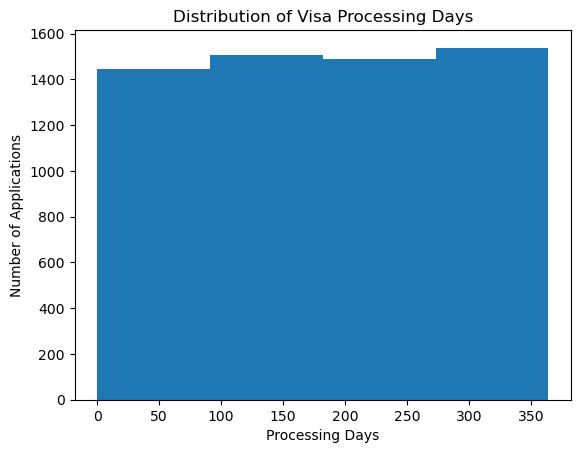

In [24]:
plt.hist(df['processing_days'],bins=4)
plt.title("Distribution of Visa Processing Days")
plt.xlabel("Processing Days")
plt.ylabel("Number of Applications")
plt.show()

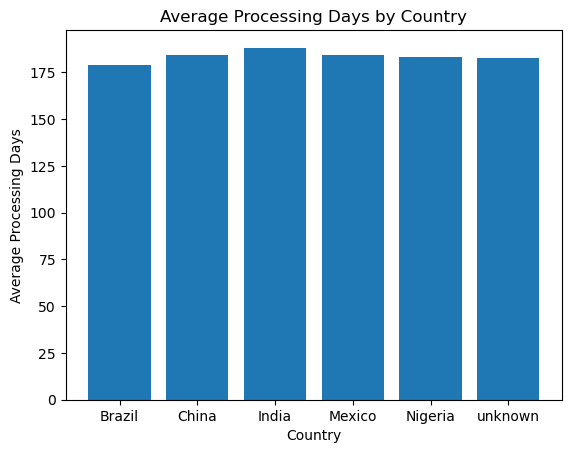

In [25]:
country_avg = df.groupby('nationality')["processing_days"].mean()

plt.figure()
plt.bar(country_avg.index, country_avg.values)

plt.title("Average Processing Days by Country")
plt.xlabel("Country")
plt.ylabel("Average Processing Days")

plt.show()

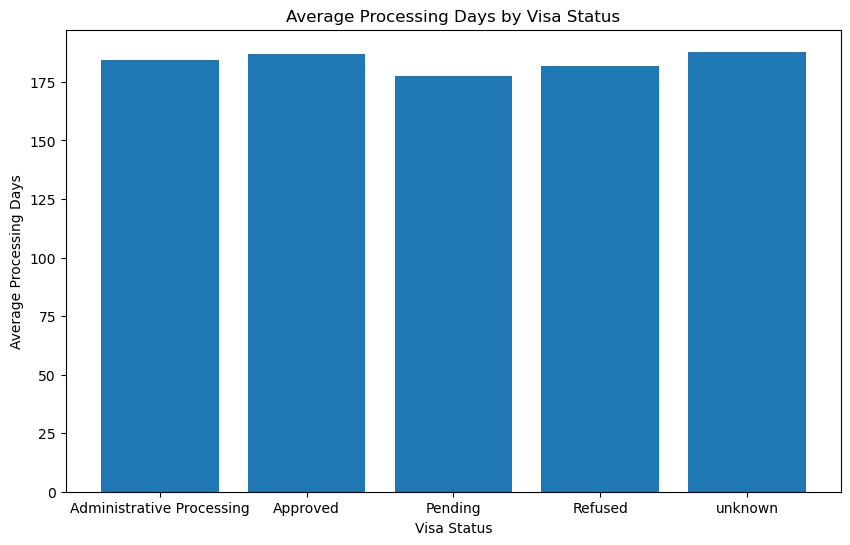

In [26]:
visa_avg = df.groupby("visa_status")["processing_days"].mean()

plt.figure(figsize=(10,6))
plt.bar(visa_avg.index, visa_avg.values)

plt.title("Average Processing Days by Visa Status")
plt.xlabel("Visa Status")
plt.ylabel("Average Processing Days")

plt.show()

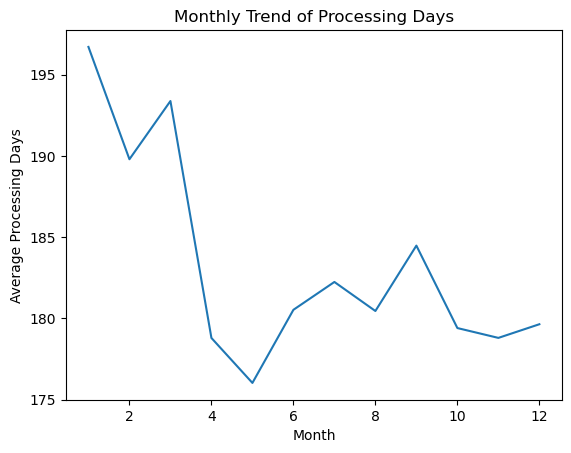

In [27]:
monthly_avg = df.groupby("application_month")["processing_days"].mean()

plt.figure()
plt.plot(monthly_avg.index, monthly_avg.values)

plt.title("Monthly Trend of Processing Days")
plt.xlabel("Month")
plt.ylabel("Average Processing Days")

plt.show()


MILESTONE 3

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [29]:
df.head(10)

,application_date,decision_date,visa_status,nationality,processing_center,applicant_age,gender,application_id,processing_days,application_month,season,country_avg,visa_avg
0,2019-11-27,2020-08-12,Approved,unknown,Dublin,35,Other,781436,259,11,Off-Peak,183.0,187.0
1,2024-02-04,2024-07-24,unknown,Nigeria,unknown,30,Other,904539,171,2,Peak,183.0,188.0
6,2022-02-26,2022-09-15,Approved,Nigeria,unknown,18,Female,439606,201,2,Peak,183.0,187.0
22,2019-01-10,2019-08-27,Approved,Nigeria,Dublin,22,Male,185883,229,1,Peak,183.0,187.0
25,2023-11-29,2024-06-07,unknown,unknown,New Delhi,30,Female,336743,191,11,Off-Peak,183.0,188.0
28,2022-05-23,2022-09-27,Administrative Processing,China,Mumbai,30,Male,893758,127,5,Off-Peak,184.0,184.0
29,2022-08-19,2022-12-02,Approved,China,New Delhi,30,Other,889924,105,8,Off-Peak,184.0,187.0
30,2020-02-27,2020-03-28,Administrative Processing,Mexico,unknown,45,Other,345944,30,2,Peak,184.0,184.0
40,2021-03-10,2021-10-10,Refused,Mexico,Mumbai,22,Male,985036,214,3,Off-Peak,184.0,182.0
56,2024-02-29,2024-12-17,Approved,Brazil,unknown,35,Female,448636,292,2,Peak,179.0,187.0


In [30]:
df=df.drop(columns=['application_id','application_month','season','country_avg','visa_avg'])

In [31]:
df.head()

,application_date,decision_date,visa_status,nationality,processing_center,applicant_age,gender,processing_days
0,2019-11-27,2020-08-12,Approved,unknown,Dublin,35,Other,259
1,2024-02-04,2024-07-24,unknown,Nigeria,unknown,30,Other,171
6,2022-02-26,2022-09-15,Approved,Nigeria,unknown,18,Female,201
22,2019-01-10,2019-08-27,Approved,Nigeria,Dublin,22,Male,229
25,2023-11-29,2024-06-07,unknown,unknown,New Delhi,30,Female,191


In [32]:
df=df.drop(columns=['processing_center','applicant_age','gender'])

In [33]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
import joblib

In [34]:
country_encoder=LabelEncoder()
visa_encoder=LabelEncoder()

In [35]:
df['nationality']=country_encoder.fit_transform(df['nationality'])
df['visa_status']=visa_encoder.fit_transform(df['visa_status'])

In [36]:
df['month']=df['application_date'].dt.month

In [37]:
X=df[['nationality','visa_status','month']]
y=df['processing_days']

In [38]:
model=RandomForestRegressor()
model.fit(X,y)

RandomForestRegressor()

In [39]:
joblib.dump(model,'rf_model.pkl')

['rf_model.pkl']

In [40]:
joblib.dump(country_encoder,'country_encoder.pkl')

['country_encoder.pkl']

In [41]:
joblib.dump(visa_encoder,'visa_encoder.pkl')

['visa_encoder.pkl']

In [42]:
model=joblib.load('rf_model.pkl')

In [43]:
country_encoder = joblib.load("country_encoder.pkl")
visa_encoder = joblib.load("visa_encoder.pkl")

In [44]:
import pandas as pd
import joblib

model=joblib.load('rf_model.pkl')
country_encoder = joblib.load("country_encoder.pkl")
visa_encoder = joblib.load("visa_encoder.pkl")


def preprocess_input(data):
    """
    Convert user input into model-ready format
    """

    df = pd.DataFrame([data])

    # Convert date
    df["application_date"] = pd.to_datetime(df["application_date"])

    # Feature Engineering
    df["month"] = df["application_date"].dt.month

    # Encode categorical variables
    df["nationality"] = country_encoder.transform(df["nationality"])
    df["visa_status"] = visa_encoder.transform(df["visa_status"])

    # Drop unused columns
    df = df[['nationality','visa_status','month']]
    
    return df


def predict_processing_time(input_data):
    """
    Takes user input → returns predicted processing time
    """

    processed_data = preprocess_input(input_data)

    prediction = model.predict(processed_data)

    return round(prediction[0], 2)
